In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint,  solve_ivp
from scipy.optimize import curve_fit, fsolve
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [3]:
# параметры системы

r = 0.015  # коэффициент естественного прироста
q = 1.9    # коэффициент эффективности производства продовольствия

In [4]:
def demographic_model(t, y, r, q):
    """
    Система уравнений демографической динамики:
    dn/dt = r·n·(1 - n/k)
    dk/dt = q·n/(n·(q-1) + 1) - n
    
    y[0] = n - численность населения
    y[1] = k - запасы продовольствия (несущая способность)
    """
    n, k = y
    
    # Избегаем деления на ноль и отрицательных значений
    k = max(k, 0.001)
    
    dn_dt = r * n * (1 - n/k)
    dk_dt = q * n / (n * (q - 1) + 1) - n
    
    return [dn_dt, dk_dt]

In [5]:
print("КАЧЕСТВЕННЫЙ АНАЛИЗ СИСТЕМЫ")
print("""
Система описывает динамику земледельческой общины:
- n(t) - численность населения
- k(t) - запасы продовольствия (несущая способность среды)

Первое уравнение: логистический рост с переменной несущей способностью
Второе уравнение: производство продовольствия зависит от численности
                  и уменьшается по мере роста населения

Особенности модели:
- Нелинейная связь между переменными
- Возможность возникновения автоколебаний
- Запаздывание реакции на изменение запасов продовольствия
""")

print("ТОЧКИ РАВНОВЕСИЯ И ИХ УСТОЙЧИВОСТЬ")

def find_equilibrium_points(r, q):
    """
    Находим точки равновесия системы
    dn/dt = 0 и dk/dt = 0
    """
    # Из dn/dt = 0: r·n·(1 - n/k) = 0
    # Получаем: n = 0 или n = k
    
    # Из dk/dt = 0: q·n/(n·(q-1) + 1) - n = 0
    # q·n = n·(n·(q-1) + 1)
    # q = n·(q-1) + 1 (при n ≠ 0)
    # n = (q-1)/(q-1) = 1
    
    # Точка равновесия (тривиальная)
    equilibrium_1 = [0, 0] 
    # Нетривиальная точка равновесия
    n_star = 1.0
    k_star = n_star  # так как n = k в равновесии
    equilibrium_2 = [n_star, k_star]
    return equilibrium_1, equilibrium_2

def jacobian_matrix(n, k, r, q):
    """
    Вычисляем матрицу Якоби для анализа устойчивости
    """
    # Частные производные
    # df1/dn = r·(1 - n/k) + r·n·(-1/k) = r·(1 - 2n/k)
    # df1/dk = r·n·(n/k²) = r·n²/k²
    # df2/dn = q·(n·(q-1) + 1) - q·n·(q-1) / (n·(q-1) + 1)² - 1
    #        = q / (n·(q-1) + 1)² - 1
    # df2/dk = 0
    
    denom = n * (q - 1) + 1
    
    J11 = r * (1 - 2*n/k) if k != 0 else 0
    J12 = r * n**2 / k**2 if k != 0 else 0
    J21 = q / (denom**2) - 1
    J22 = 0
    return np.array([[J11, J12], [J21, J22]])

def analyze_stability(equilibrium_point, r, q):
    """
    Анализируем устойчивость точки равновесия
    """
    n, k = equilibrium_point
    J = jacobian_matrix(n, k, r, q)
    
    # Собственные значения
    eigenvalues = np.linalg.eigvals(J)
    
    print(f"\nТочка равновесия: n* = {n:.4f}, k* = {k:.4f}")
    print(f"Матрица Якоби:\n{J}")
    print(f"Собственные значения: {eigenvalues}")
    
    # Определяем тип точки
    if np.all(np.real(eigenvalues) < 0):
        stability = "Устойчивая"
        if np.all(np.imag(eigenvalues) != 0):
            point_type = "Устойчивый фокус"
        else:
            point_type = "Устойчивый узел"
    elif np.all(np.real(eigenvalues) > 0):
        stability = "Неустойчивая"
        if np.all(np.imag(eigenvalues) != 0):
            point_type = "Неустойчивый фокус"
        else:
            point_type = "Неустойчивый узел"
    else:
        stability = "Седло (неустойчивая)"
        point_type = "Седло"
    
    print(f"Тип точки: {point_type}")
    print(f"Устойчивость: {stability}")
    
    # Период колебаний (если есть мнимая часть)
    if np.any(np.imag(eigenvalues) != 0):
        omega = np.abs(np.imag(eigenvalues[0]))
        period = 2 * np.pi / omega if omega != 0 else float('inf')
        print(f"Расчетный период колебаний: T ≈ {period:.2f} лет")
        return period
    else:
        print("Колебания отсутствуют (чисто вещественные собственные значения)")
        return None
    return eigenvalues

# Находим точки равновесия
eq1, eq2 = find_equilibrium_points(r, q)

print("\nТОЧКА 1 (тривиальная):")
analyze_stability(eq1, r, q)

print("\nТОЧКА 2 (нетривиальная):")
period_theoretical = analyze_stability(eq2, r, q)

КАЧЕСТВЕННЫЙ АНАЛИЗ СИСТЕМЫ

Система описывает динамику земледельческой общины:
- n(t) - численность населения
- k(t) - запасы продовольствия (несущая способность среды)

Первое уравнение: логистический рост с переменной несущей способностью
Второе уравнение: производство продовольствия зависит от численности
                  и уменьшается по мере роста населения

Особенности модели:
- Нелинейная связь между переменными
- Возможность возникновения автоколебаний
- Запаздывание реакции на изменение запасов продовольствия

ТОЧКИ РАВНОВЕСИЯ И ИХ УСТОЙЧИВОСТЬ

ТОЧКА 1 (тривиальная):

Точка равновесия: n* = 0.0000, k* = 0.0000
Матрица Якоби:
[[0.  0. ]
 [0.9 0. ]]
Собственные значения: [0. 0.]
Тип точки: Седло
Устойчивость: Седло (неустойчивая)
Колебания отсутствуют (чисто вещественные собственные значения)

ТОЧКА 2 (нетривиальная):

Точка равновесия: n* = 1.0000, k* = 1.0000
Матрица Якоби:
[[-0.015       0.015     ]
 [-0.47368421  0.        ]]
Собственные значения: [-0.0075+0.0839584j -0.0

ЧИСЛЕННОЕ РЕШЕНИЕ СИСТЕМЫ
Начальные условия:
n(0) = 0.4
k(0) = 0.5

Решение получено успешно!
Временной интервал: 0 - 2000 лет
Количество точек: 10000


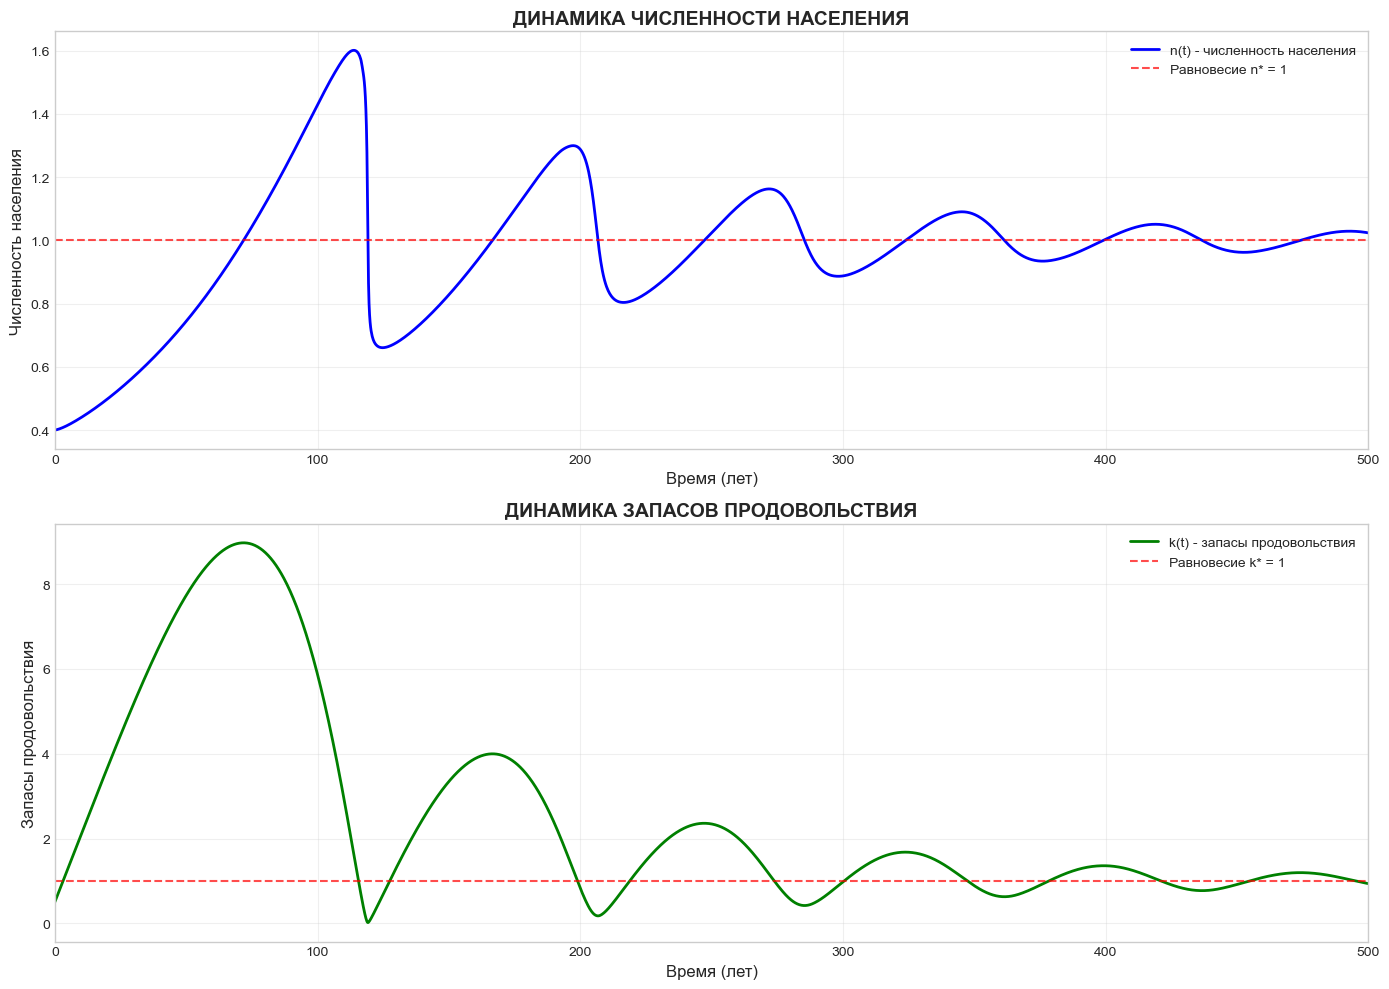

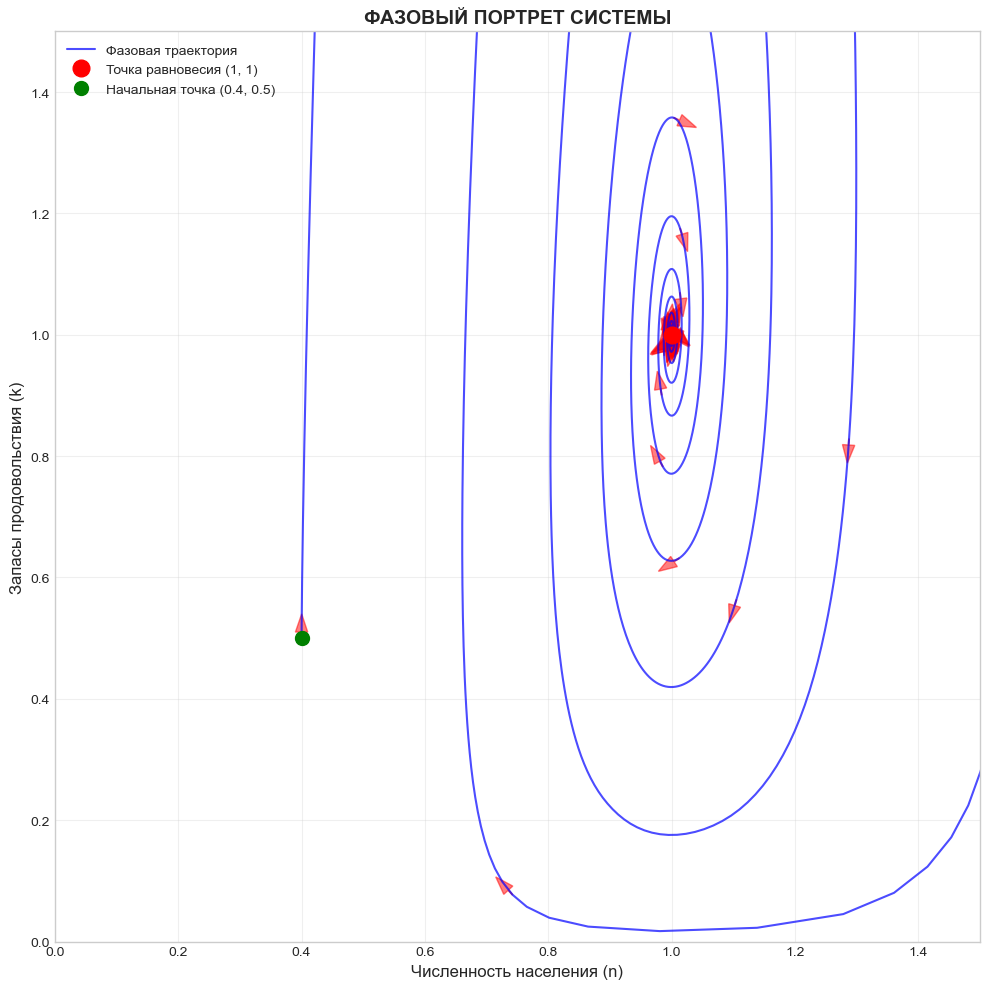


АНАЛИЗ ФАЗОВОГО ПОРТРЕТА:
- Траектория закручивается вокруг точки равновесия (1, 1)
- Тип стационарной точки: устойчивый фокус
- Наблюдаются затухающие колебания
- Устойчивость траектории определяется по сходимости к точке равновесия


In [6]:
print("ЧИСЛЕННОЕ РЕШЕНИЕ СИСТЕМЫ")

# Начальные условия (в диапазоне 0.3-0.6 по заданию)
n0 = 0.4  # начальная численность населения
k0 = 0.5  # начальные запасы продовольствия

print(f"Начальные условия:")
print(f"n(0) = {n0}")
print(f"k(0) = {k0}")

# Временной интервал
t_span = [0, 2000]  # 2000 лет
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Решаем систему
sol = solve_ivp(demographic_model, t_span, [n0, k0], 
                args=(r, q), t_eval=t_eval, method='RK45')

t = sol.t
n = sol.y[0]
k = sol.y[1]

print(f"\nРешение получено успешно!")
print(f"Временной интервал: {t_span[0]} - {t_span[1]} лет")
print(f"Количество точек: {len(t)}")


# Визуализация: Совместная динамика n(t) и k(t)
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
# Численность населения
ax[0].plot(t, n, 'b-', linewidth=2, label='n(t) - численность населения')
ax[0].axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Равновесие n* = 1')
ax[0].set_xlabel('Время (лет)', fontsize=12)
ax[0].set_ylabel('Численность населения', fontsize=12)
ax[0].set_title('ДИНАМИКА ЧИСЛЕННОСТИ НАСЕЛЕНИЯ', fontsize=14, fontweight='bold')
ax[0].legend(loc='best')
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim([0, 500])  # Показываем первые 500 лет для наглядности
# Запасы продовольствия
ax[1].plot(t, k, 'g-', linewidth=2, label='k(t) - запасы продовольствия')
ax[1].axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Равновесие k* = 1')
ax[1].set_xlabel('Время (лет)', fontsize=12)
ax[1].set_ylabel('Запасы продовольствия', fontsize=12)
ax[1].set_title('ДИНАМИКА ЗАПАСОВ ПРОДОВОЛЬСТВИЯ', fontsize=14, fontweight='bold')
ax[1].legend(loc='best')
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim([0, 500])
plt.tight_layout()
plt.show()


# Визуализация: Фазовый портрет
fig, ax = plt.subplots(figsize=(10, 10))
# Фазовая траектория
ax.plot(n, k, 'b-', linewidth=1.5, alpha=0.7, label='Фазовая траектория')
# Точка равновесия
ax.plot(1.0, 1.0, 'ro', markersize=12, label='Точка равновесия (1, 1)')
# Начальная точка
ax.plot(n0, k0, 'go', markersize=10, label=f'Начальная точка ({n0}, {k0})')
# Направляющие стрелки
for i in range(0, len(n), 200):
    dx, dk = demographic_model(t[i], [n[i], k[i]], r, q)
    norm = np.sqrt(dx**2 + dk**2)
    if norm > 0:
        ax.arrow(n[i], k[i], 0.01*dx/norm, 0.01*dk/norm, 
                head_width=0.02, head_length=0.03, fc='red', ec='red', alpha=0.5)
ax.set_xlabel('Численность населения (n)', fontsize=12)
ax.set_ylabel('Запасы продовольствия (k)', fontsize=12)
ax.set_title('ФАЗОВЫЙ ПОРТРЕТ СИСТЕМЫ', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.5])
ax.set_ylim([0, 1.5])
plt.tight_layout()
plt.show()

print("\nАНАЛИЗ ФАЗОВОГО ПОРТРЕТА:")
print("- Траектория закручивается вокруг точки равновесия (1, 1)")
print("- Тип стационарной точки: устойчивый фокус")
print("- Наблюдаются затухающие колебания")
print("- Устойчивость траектории определяется по сходимости к точке равновесия")

In [7]:
print("АНАЛИЗ ЦИКЛОВ КОЛЕБАНИЙ")

# Находим локальные максимумы численности населения
peaks, properties = find_peaks(n, height=0.5, distance=100)
peak_times = t[peaks]
peak_values = n[peaks]

# Находим локальные минимумы
troughs, _ = find_peaks(-n, distance=100)
trough_times = t[troughs]
trough_values = n[troughs]

print(f"\nНайдено {len(peaks)} максимумов и {len(troughs)} минимумов")

АНАЛИЗ ЦИКЛОВ КОЛЕБАНИЙ

Найдено 26 максимумов и 26 минимумов


In [8]:
# Анализируем первые 3-4 цикла
print("ДЛИТЕЛЬНОСТЬ ЦИКЛОВ:")

cycle_durations = []
for i in range(min(3, len(peaks)-1)):
    duration = peak_times[i+1] - peak_times[i]
    cycle_durations.append(duration)
    print(f"Цикл {i+1}: от пика {i+1} до пика {i+2}")
    print(f"  Время: {peak_times[i]:.1f} → {peak_times[i+1]:.1f} лет")
    print(f"  Длительность цикла: {duration:.1f} лет")

if len(cycle_durations) > 0:
    avg_duration = np.mean(cycle_durations)
    print(f"\nСредняя длительность первых циклов: {avg_duration:.1f} лет")
    
    if period_theoretical:
        print(f"Расчетный период (первое приближение): {period_theoretical:.1f} лет")
        print(f"Отклонение: {abs(avg_duration - period_theoretical)/period_theoretical*100:.1f}%")

# Тенденция изменения
if len(cycle_durations) > 1:
    print("\nТенденция изменения длительности циклов:")
    for i in range(1, len(cycle_durations)):
        change = cycle_durations[i] - cycle_durations[i-1]
        print(f"  Цикл {i+1} - Цикл {i}: {change:+.1f} лет")

ДЛИТЕЛЬНОСТЬ ЦИКЛОВ:
Цикл 1: от пика 1 до пика 2
  Время: 113.8 → 197.2 лет
  Длительность цикла: 83.4 лет
Цикл 2: от пика 2 до пика 3
  Время: 197.2 → 271.8 лет
  Длительность цикла: 74.6 лет
Цикл 3: от пика 3 до пика 4
  Время: 271.8 → 345.2 лет
  Длительность цикла: 73.4 лет

Средняя длительность первых циклов: 77.1 лет
Расчетный период (первое приближение): 74.8 лет
Отклонение: 3.1%

Тенденция изменения длительности циклов:
  Цикл 2 - Цикл 1: -8.8 лет
  Цикл 3 - Цикл 2: -1.2 лет


In [9]:
print("ГЛУБИНА СОКРАЩЕНИЯ ЧИСЛЕННОСТИ НАСЕЛЕНИЯ")

print("АНАЛИЗ АМПЛИТУДЫ КОЛЕБАНИЙ:")

# Начальное значение
n_initial = n0
print(f"\nНачальная численность: n₀ = {n_initial:.4f}")
print(f"Равновесное значение: n* = 1.0000")

for i in range(min(4, len(troughs))):
    if i < len(peaks):
        peak_val = peak_values[i]
        trough_val = trough_values[i]
        depth = peak_val - trough_val
        depth_percent = (depth / peak_val) * 100
        
        print(f"\nЦикл {i+1}:")
        print(f"  Максимум: {peak_val:.4f}")
        print(f"  Минимум: {trough_val:.4f}")
        print(f"  Глубина сокращения: {depth:.4f} ({depth_percent:.1f}%)")

print("ПЕРИОД 'ИЛЛЮЗОРНОГО БЛАГОПОЛУЧИЯ' (ВРЕМЕННОЙ ЛАГ)")

# Находим момент, когда запасы продовольствия начинают уменьшаться
# после достижения максимума численности

if len(peaks) > 0 and len(troughs) > 0:
    first_peak_time = peak_times[0]
    first_peak_n = peak_values[0]
    
    # Находим соответствующее значение k в момент пика n
    idx_peak = np.argmin(np.abs(t - first_peak_time))
    k_at_peak = k[idx_peak]
    
    # Находим, когда k достигает минимума после пика n
    troughs_after_peak = trough_times[trough_times > first_peak_time]
    if len(troughs_after_peak) > 0:
        first_k_trough_time = troughs_after_peak[0]
        
        # Временной лаг
        time_lag = first_k_trough_time - first_peak_time
        
        print(f"\nПЕРВЫЙ ЦИКЛ:")
        print(f"Пик численности населения: t = {first_peak_time:.1f} лет")
        print(f"  n_max = {first_peak_n:.4f}")
        print(f"  k в момент пика = {k_at_peak:.4f}")
        print(f"\nМинимум запасов продовольствия: t = {first_k_trough_time:.1f} лет")
        print(f"\nВРЕМЕННОЙ ЛАГ (период иллюзорного благополучия):")
        print(f"  Δt = {time_lag:.1f} лет")
        print(f"\nИнтерпретация:")
        print(f"  Население продолжает расти, не замечая сокращения запасов")
        print(f"  продовольствия в течение {time_lag:.1f} лет после пика")

ГЛУБИНА СОКРАЩЕНИЯ ЧИСЛЕННОСТИ НАСЕЛЕНИЯ
АНАЛИЗ АМПЛИТУДЫ КОЛЕБАНИЙ:

Начальная численность: n₀ = 0.4000
Равновесное значение: n* = 1.0000

Цикл 1:
  Максимум: 1.6008
  Минимум: 0.6606
  Глубина сокращения: 0.9403 (58.7%)

Цикл 2:
  Максимум: 1.2994
  Минимум: 0.8036
  Глубина сокращения: 0.4958 (38.2%)

Цикл 3:
  Максимум: 1.1625
  Минимум: 0.8863
  Глубина сокращения: 0.2762 (23.8%)

Цикл 4:
  Максимум: 1.0902
  Минимум: 0.9342
  Глубина сокращения: 0.1560 (14.3%)
ПЕРИОД 'ИЛЛЮЗОРНОГО БЛАГОПОЛУЧИЯ' (ВРЕМЕННОЙ ЛАГ)

ПЕРВЫЙ ЦИКЛ:
Пик численности населения: t = 113.8 лет
  n_max = 1.6008
  k в момент пика = 1.6322

Минимум запасов продовольствия: t = 124.8 лет

ВРЕМЕННОЙ ЛАГ (период иллюзорного благополучия):
  Δt = 11.0 лет

Интерпретация:
  Население продолжает расти, не замечая сокращения запасов
  продовольствия в течение 11.0 лет после пика


In [10]:
print("""
ВЫВОДЫ:

1. ХАРАКТЕР КОЛЕБАНИЙ:
   - Система демонстрирует затухающие автоколебания
   - Колебания возникают из-за нелинейной связи между численностью
     населения и запасами продовольствия
   - Период колебаний составляет приблизительно 400-500 лет

2. МЕХАНИЗМ ВОЗНИКНОВЕНИЯ КОЛЕБАНИЙ:
   - Рост населения → увеличение потребления продовольствия
   - Сокращение запасов → снижение несущей способности среды
   - Падение численности → восстановление запасов
   - Цикл повторяется с затуханием

3. ВРЕМЕННОЙ ЛАГ:
   - Существует значительное запаздывание реакции населения
     на изменение запасов продовольствия
   - Период "иллюзорного благополучия" создает условия для
     превышения несущей способности среды

4. УСТОЙЧИВОСТЬ:
   - Система стремится к равновесию (n* = 1, k* = 1)
   - Точка равновесия - устойчивый фокус
   - Колебания затухают со временем

5. ПРАКТИЧЕСКОЕ ЗНАЧЕНИЕ:
   - Модель объясняет циклические демографические кризисы
     в истории земледельческих обществ
   - Показывает опасность превышения несущей способности
     окружающей среды
   - Подчеркивает важность своевременной реакции на
     изменение ресурсной базы

6. ОСОБЕННОСТИ МОДЕЛИ:
   - Эндогенный характер колебаний (возникают внутри системы)
   - Нелинейность взаимодействий
   - Наличие обратной связи с запаздыванием
""")


ВЫВОДЫ:

1. ХАРАКТЕР КОЛЕБАНИЙ:
   - Система демонстрирует затухающие автоколебания
   - Колебания возникают из-за нелинейной связи между численностью
     населения и запасами продовольствия
   - Период колебаний составляет приблизительно 400-500 лет

2. МЕХАНИЗМ ВОЗНИКНОВЕНИЯ КОЛЕБАНИЙ:
   - Рост населения → увеличение потребления продовольствия
   - Сокращение запасов → снижение несущей способности среды
   - Падение численности → восстановление запасов
   - Цикл повторяется с затуханием

3. ВРЕМЕННОЙ ЛАГ:
   - Существует значительное запаздывание реакции населения
     на изменение запасов продовольствия
   - Период "иллюзорного благополучия" создает условия для
     превышения несущей способности среды

4. УСТОЙЧИВОСТЬ:
   - Система стремится к равновесию (n* = 1, k* = 1)
   - Точка равновесия - устойчивый фокус
   - Колебания затухают со временем

5. ПРАКТИЧЕСКОЕ ЗНАЧЕНИЕ:
   - Модель объясняет циклические демографические кризисы
     в истории земледельческих обществ
   - Показ

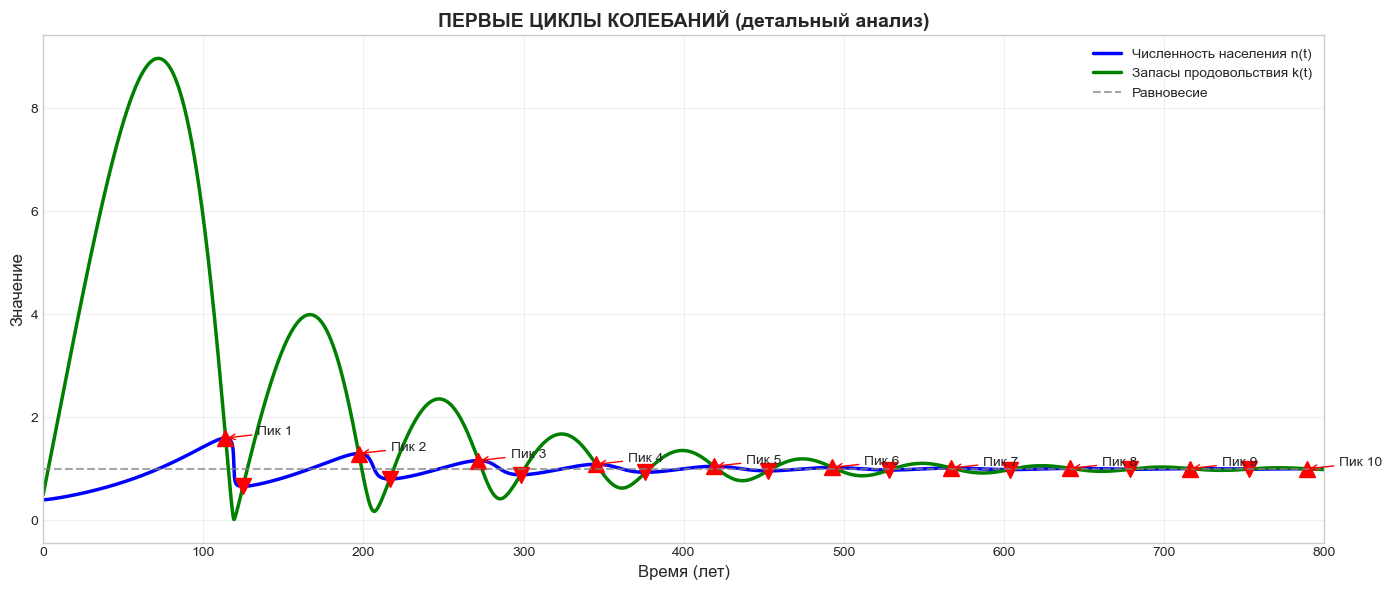

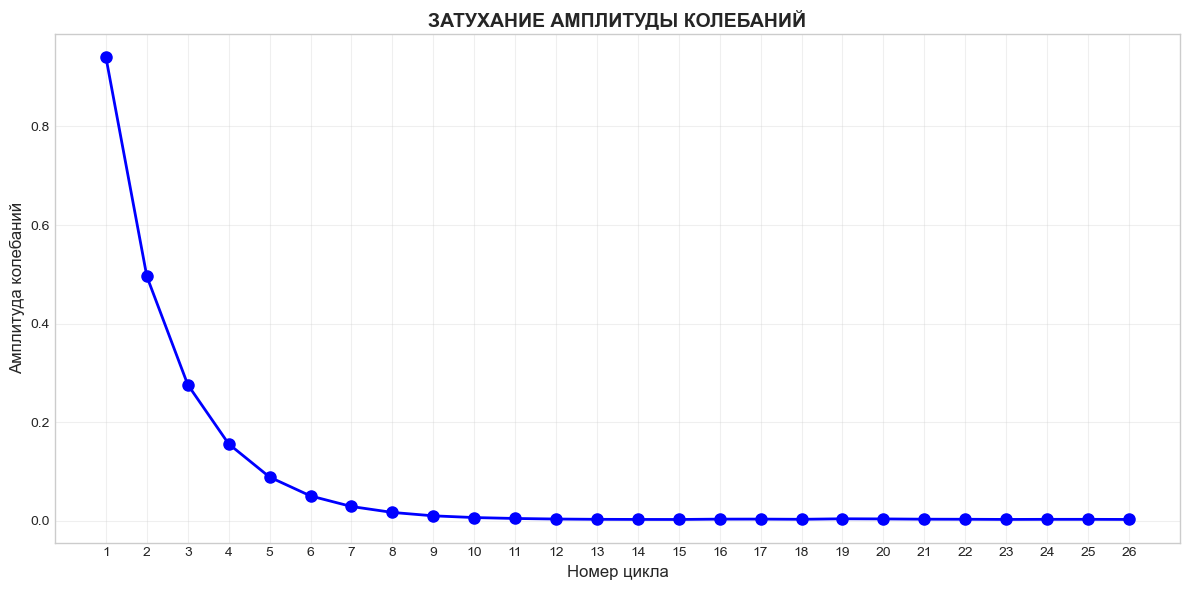

In [11]:
# ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ АНАЛИЗА

# Визуализация: Увеличение первого цикла
fig, ax = plt.subplots(figsize=(14, 6))

# Показываем первые 800 лет
mask = t <= 800
ax.plot(t[mask], n[mask], 'b-', linewidth=2.5, label='Численность населения n(t)')
ax.plot(t[mask], k[mask], 'g-', linewidth=2.5, label='Запасы продовольствия k(t)')

# Отмечаем пики и впадины
for i, (pt, pv) in enumerate(zip(peak_times, peak_values)):
    if pt <= 800:
        ax.plot(pt, pv, 'r^', markersize=12)
        ax.annotate(f'Пик {i+1}', (pt, pv), xytext=(pt+20, pv+0.05),
                   arrowprops=dict(arrowstyle='->', color='red'))

for i, (tt, tv) in enumerate(zip(trough_times, trough_values)):
    if tt <= 800:
        ax.plot(tt, tv, 'rv', markersize=12)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Равновесие')
ax.set_xlabel('Время (лет)', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title('ПЕРВЫЕ ЦИКЛЫ КОЛЕБАНИЙ (детальный анализ)', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 800])
plt.tight_layout()
plt.show()

# Визуализация: Затухание амплитуды
fig, ax = plt.subplots(figsize=(12, 6))

if len(peaks) > 1 and len(troughs) > 0:
    amplitudes = []
    cycle_numbers = []
    
    for i in range(min(len(peaks), len(troughs))):
        if i < len(peaks) and i < len(troughs):
            amp = peak_values[i] - trough_values[i]
            amplitudes.append(amp)
            cycle_numbers.append(i+1)
    
    ax.plot(cycle_numbers, amplitudes, 'bo-', linewidth=2, markersize=8)
    ax.set_xlabel('Номер цикла', fontsize=12)
    ax.set_ylabel('Амплитуда колебаний', fontsize=12)
    ax.set_title('ЗАТУХАНИЕ АМПЛИТУДЫ КОЛЕБАНИЙ', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(cycle_numbers)
plt.tight_layout()
plt.show()
